# Diabetes Classification & Clustering
## Multi-Class Prediction of Diabetes Status

**Classes:** N = Non-diabetic | Y = Diabetic | P = Predict-diabetic

**Author:** Aananda Giri  
**Date:** 2026-05-19

## 0. Imports and Configuration

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             ConfusionMatrixDisplay, silhouette_score,
                             adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_score, completeness_score, v_measure_score,
                             davies_bouldin_score, calinski_harabasz_score)

# XGBoost
from xgboost import XGBClassifier

# Imbalanced learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Clustering & Dimensionality Reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting defaults
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print('All imports successful.')

All imports successful.


## 1. Data Loading and Initial Inspection

In [2]:
# Load CSV — uses \\r line terminators (legacy Mac format)
df = pd.read_csv('Diabetes Dataset/Dataset of Diabetes .csv', lineterminator='\r')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape: (1001, 14)
Columns: ['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975.0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221.0,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975.0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656.0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223.0,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
5,634,34224.0,F,45.0,2.3,24.0,4.0,2.9,1.0,1.0,1.5,0.4,21.0,N
6,721,34225.0,F,50.0,2.0,50.0,4.0,3.6,1.3,0.9,2.1,0.6,24.0,N
7,421,34227.0,M,48.0,4.7,47.0,4.0,2.9,0.8,0.9,1.6,0.4,24.0,N
8,670,34229.0,M,43.0,2.6,67.0,4.0,3.8,0.9,2.4,3.7,1.0,21.0,N
9,759,34230.0,F,32.0,3.6,28.0,4.0,3.8,2.0,2.4,3.8,1.0,24.0,N


In [3]:
# Data types and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1001 non-null   str    
 1   No_Pation  1000 non-null   float64
 2   Gender     1000 non-null   str    
 3   AGE        1000 non-null   float64
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   float64
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   str    
dtypes: float64(11), str(3)
memory usage: 109.6 KB


In [4]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('No missing values found.')
else:
    print('Missing values per column:')
    print(missing)
    print(f'\nDropping {df.isnull().any(axis=1).sum()} row(s) with missing values...')
    df = df.dropna()
    print(f'Shape after dropping NAs: {df.shape}')

Missing values per column:
No_Pation    1
Gender       1
AGE          1
Urea         1
Cr           1
HbA1c        1
Chol         1
TG           1
HDL          1
LDL          1
VLDL         1
BMI          1
CLASS        1
dtype: int64

Dropping 1 row(s) with missing values...
Shape after dropping NAs: (1000, 14)


In [5]:
# Drop identifier columns (ID and No_Pation are just row identifiers)
df = df.drop(columns=['ID', 'No_Pation'])
print(f'Shape after dropping IDs: {df.shape}')
df.head()

Shape after dropping IDs: (1000, 12)


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [6]:
# Standardize categorical columns
df['Gender'] = df['Gender'].str.strip().str.upper()
df['CLASS'] = df['CLASS'].str.strip()

# Verify
print(f'Unique Gender values: {df["Gender"].unique()}')
print(f'Unique CLASS values: {df["CLASS"].unique()}')
print(f'\nGender distribution:')
print(df['Gender'].value_counts())

Unique Gender values: <StringArray>
['F', 'M']
Length: 2, dtype: str
Unique CLASS values: <StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str

Gender distribution:
Gender
M    565
F    435
Name: count, dtype: int64


## 2. Exploratory Data Analysis — Univariate

### 2.1 Target Variable Distribution

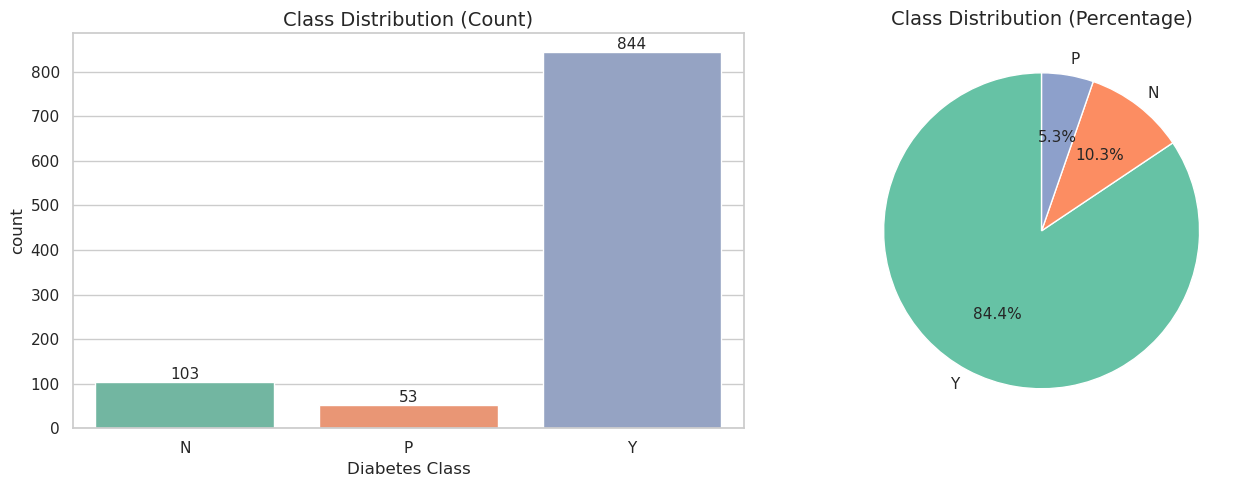

Class Distribution Summary:
       Count  Percentage
CLASS                   
Y        844        84.4
N        103        10.3
P         53         5.3

Imbalance ratio (largest/smallest): 15.9:1


In [7]:
# Class distribution
class_counts = df['CLASS'].value_counts()
class_pct = df['CLASS'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='CLASS', order=['N', 'P', 'Y'], palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Diabetes Class')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 3), startangle=90)
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

# Summary stat table
summary = pd.DataFrame({'Count': class_counts, 'Percentage': class_pct.round(2)})
print('Class Distribution Summary:')
print(summary)
print(f'\nImbalance ratio (largest/smallest): {class_counts.max() / class_counts.min():.1f}:1')

### 2.2 Numeric Feature Summary Statistics

In [8]:
# Summary statistics for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric features ({len(numeric_cols)}): {numeric_cols}\n')
df[numeric_cols].describe().T

Numeric features (10): ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']



,count,mean,std,min,25%,50%,75%,max
AGE,1000.0,53.528000,8.799241,20.0,51.0,55.0,59.0,79.00
Urea,1000.0,5.124743,2.935165,0.5,3.7,4.6,5.7,38.90
Cr,1000.0,68.943000,59.984747,6.0,48.0,60.0,73.0,800.00
HbA1c,1000.0,8.281160,2.534003,0.9,6.5,8.0,10.2,16.00
Chol,1000.0,4.862820,1.301738,0.0,4.0,4.8,5.6,10.30
TG,1000.0,2.349610,1.401176,0.3,1.5,2.0,2.9,13.80
HDL,1000.0,1.204750,0.660414,0.2,0.9,1.1,1.3,9.90
LDL,1000.0,2.609790,1.115102,0.3,1.8,2.5,3.3,9.90
VLDL,1000.0,1.854700,3.663599,0.1,0.7,0.9,1.5,35.00
BMI,1000.0,29.578020,4.962388,19.0,26.0,30.0,33.0,47.75


### 2.3 Feature Distributions — Histograms with KDE

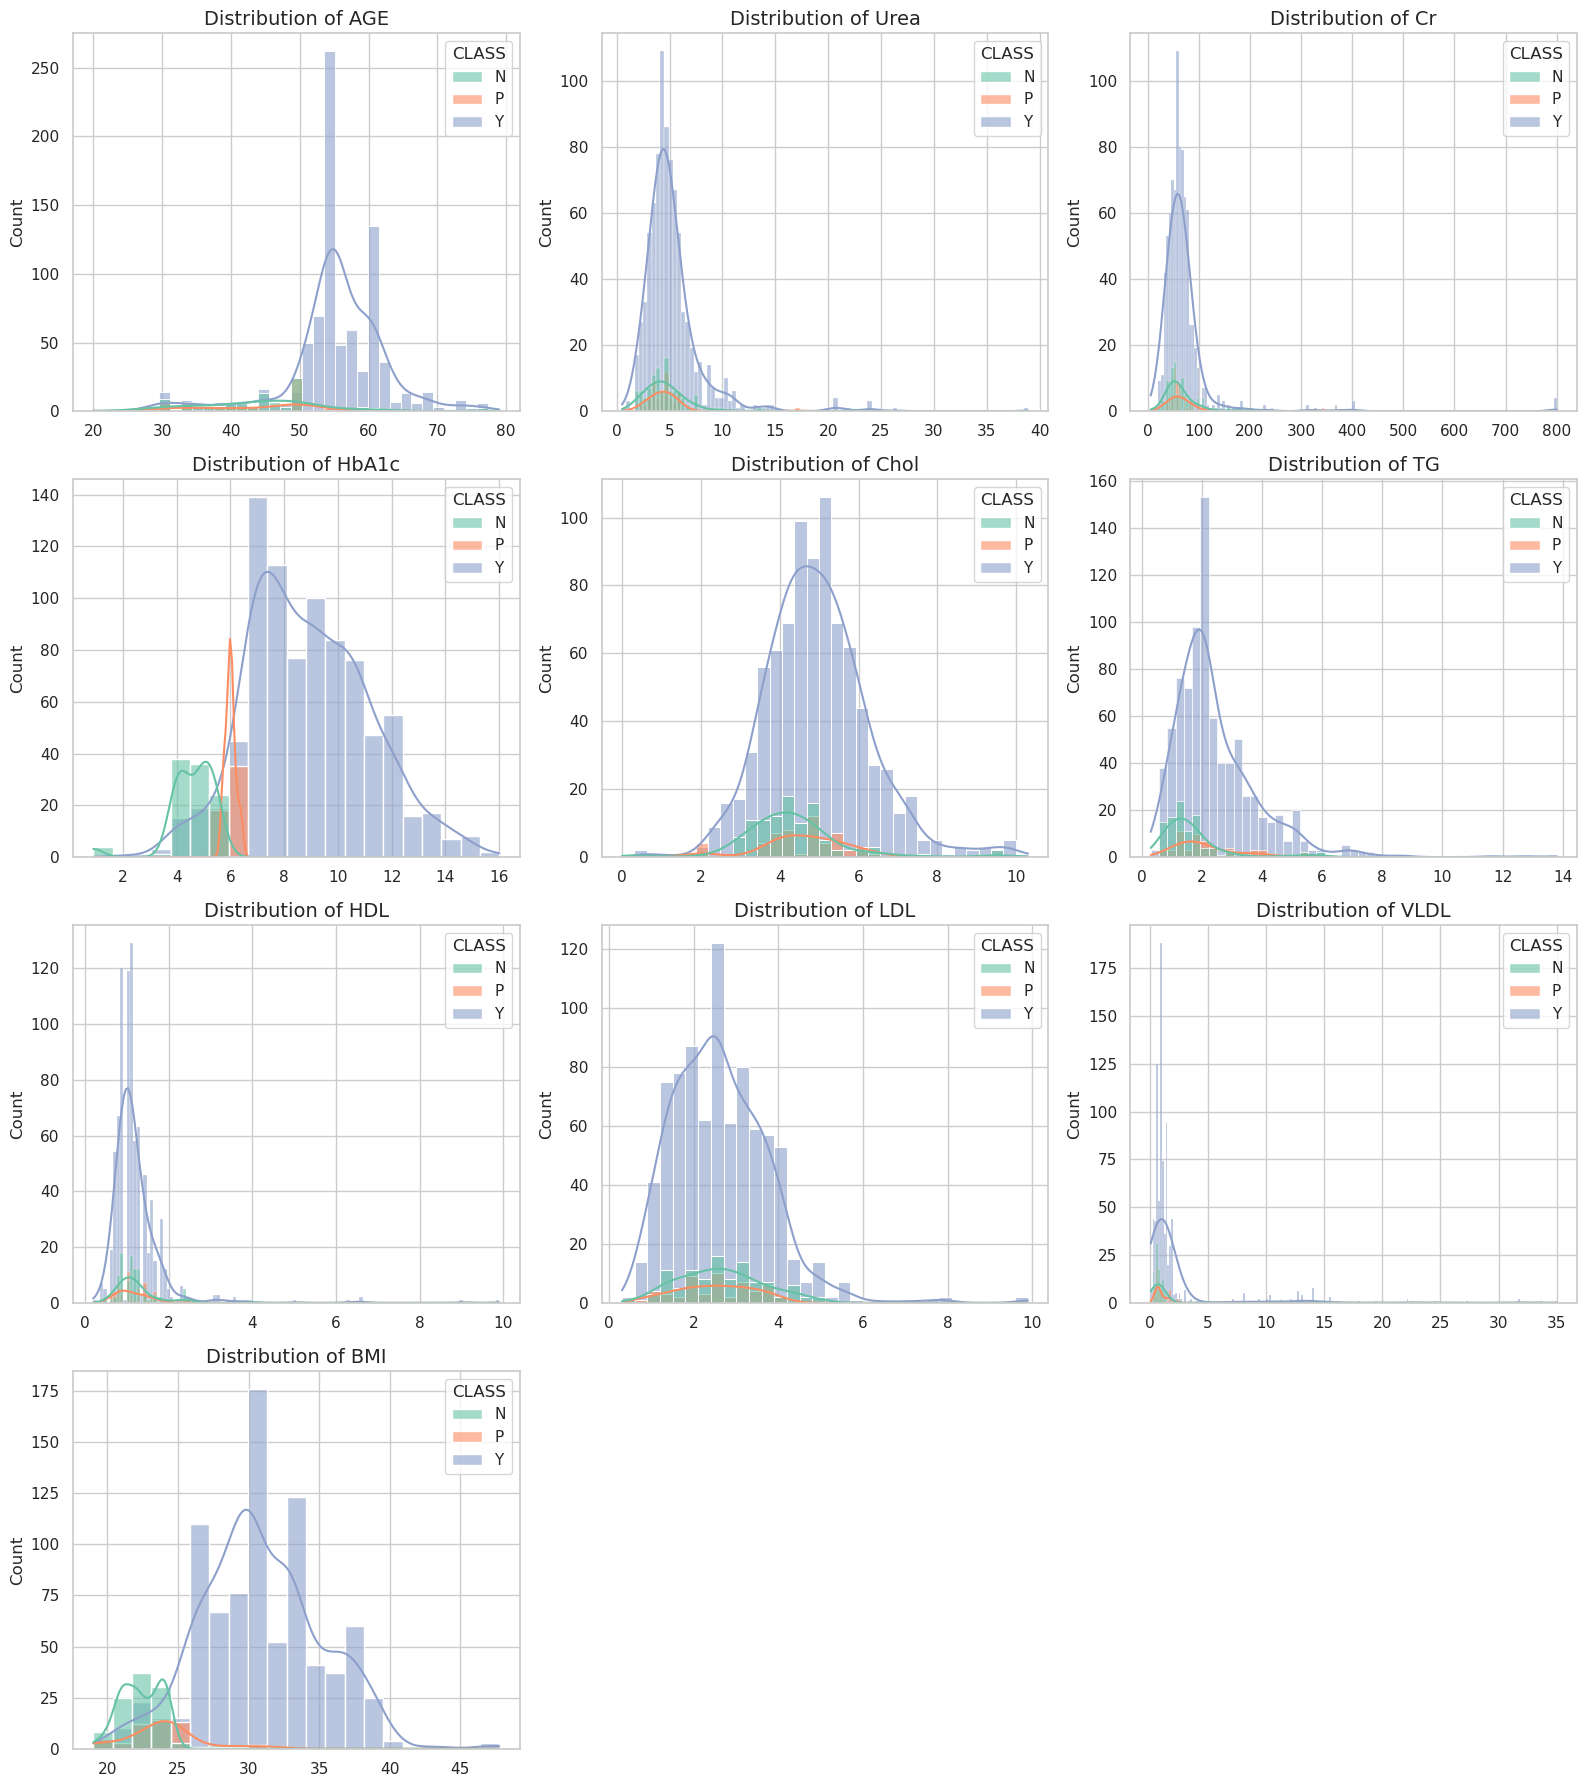

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, hue='CLASS', palette='Set2', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

# Hide any extra subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 2.4 Skewness Analysis

Skewness of numeric features:
  Cr        :  +8.474  (right-skewed)
  HDL       :  +6.283  (right-skewed)
  VLDL      :  +5.350  (right-skewed)
  Urea      :  +4.299  (right-skewed)
  TG        :  +2.298  (right-skewed)
  LDL       :  +1.146  (right-skewed)
  Chol      :  +0.617  (right-skewed)
  HbA1c     :  +0.222  (symmetric-skewed)
  BMI       :  +0.126  (symmetric-skewed)
  AGE       :  -0.820  (left-skewed)


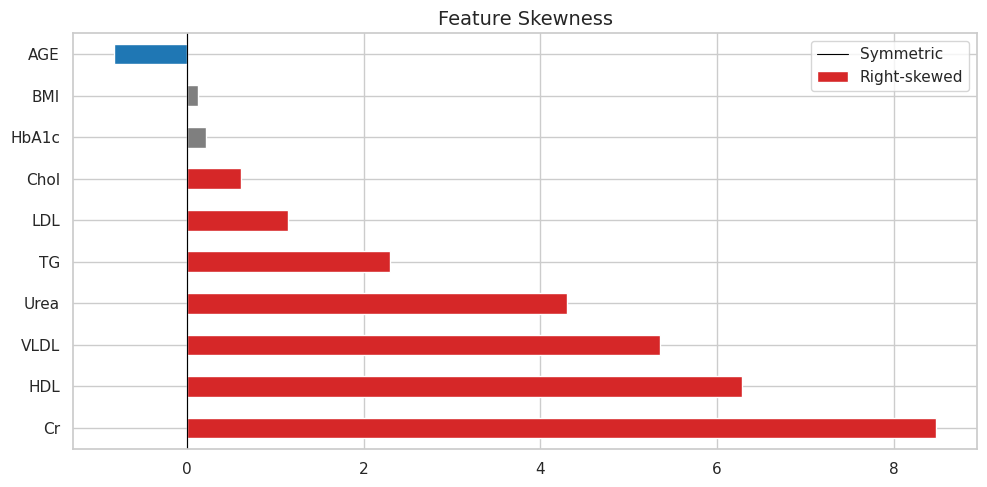

In [10]:
# Skewness per numeric feature
skew = df[numeric_cols].skew().sort_values(ascending=False)
print('Skewness of numeric features:')
for col, val in skew.items():
    direction = 'right' if val > 0.5 else ('left' if val < -0.5 else 'symmetric')
    print(f'  {col:10s}: {val:+7.3f}  ({direction}-skewed)')

# Bar plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if v > 0.5 else '#1f77b4' if v < -0.5 else '#7f7f7f' for v in skew.values]
skew.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Skewness')
ax.legend(['Symmetric', 'Right-skewed', 'Left-skewed'])
plt.tight_layout()
plt.show()

### 2.5 Gender Distribution

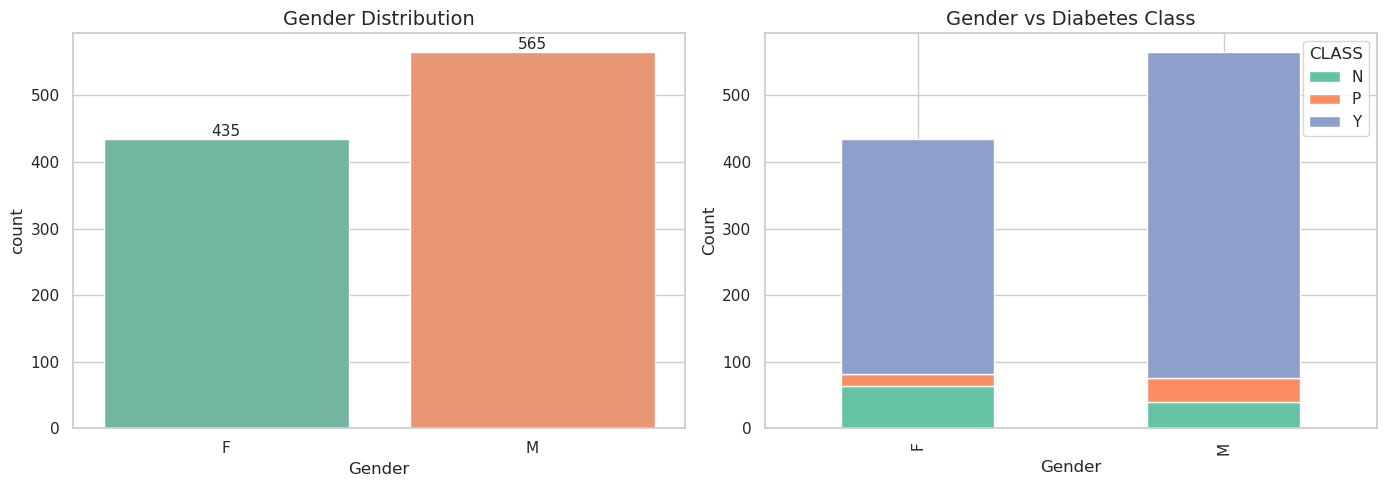

Gender x CLASS Crosstab:
CLASS    N   P    Y
Gender             
F       64  17  354
M       39  36  490

Gender proportions:
Gender
M    56.5
F    43.5
Name: proportion, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender count
sns.countplot(data=df, x='Gender', palette='Set2', ax=axes[0])
axes[0].set_title('Gender Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# Gender vs CLASS
gender_class = pd.crosstab(df['Gender'], df['CLASS'])
gender_class.plot(kind='bar', stacked=True, ax=axes[1], color=sns.color_palette('Set2', 3))
axes[1].set_title('Gender vs Diabetes Class')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

print('Gender x CLASS Crosstab:')
print(gender_class)
print(f'\nGender proportions:')
print(df['Gender'].value_counts(normalize=True).mul(100).round(2))

## 3. Exploratory Data Analysis — Bivariate

### 3.1 Feature vs Class — Boxplots

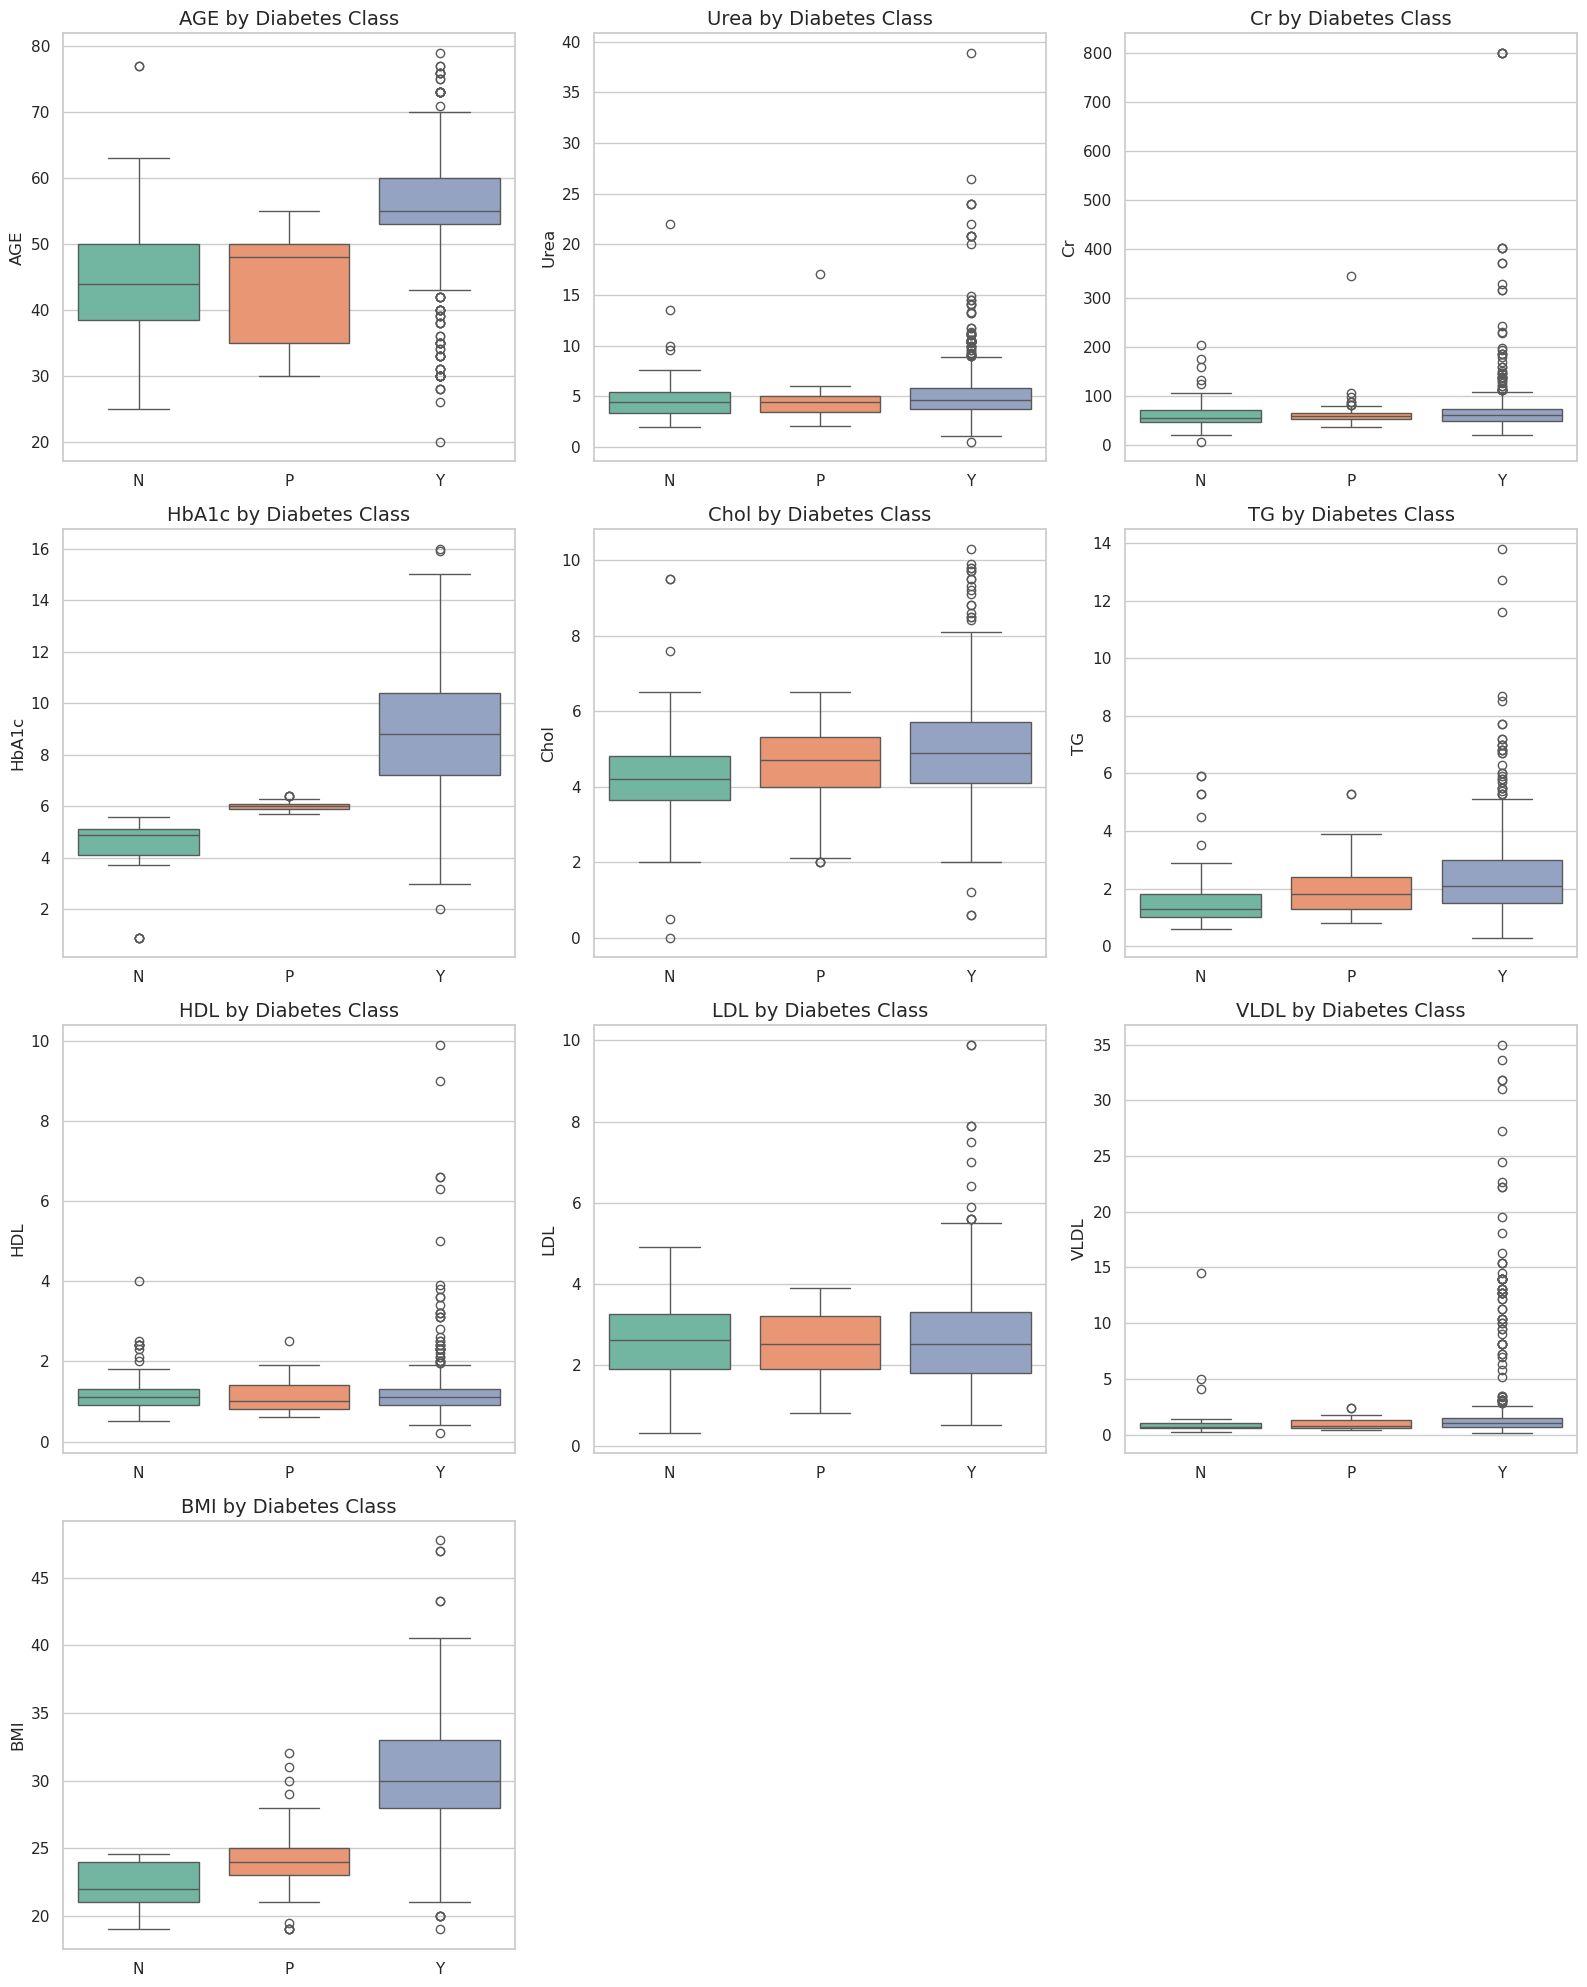

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='CLASS', y=col, order=['N', 'P', 'Y'], palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} by Diabetes Class')
    axes[i].set_xlabel('')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2 Feature vs Class — Violin Plots

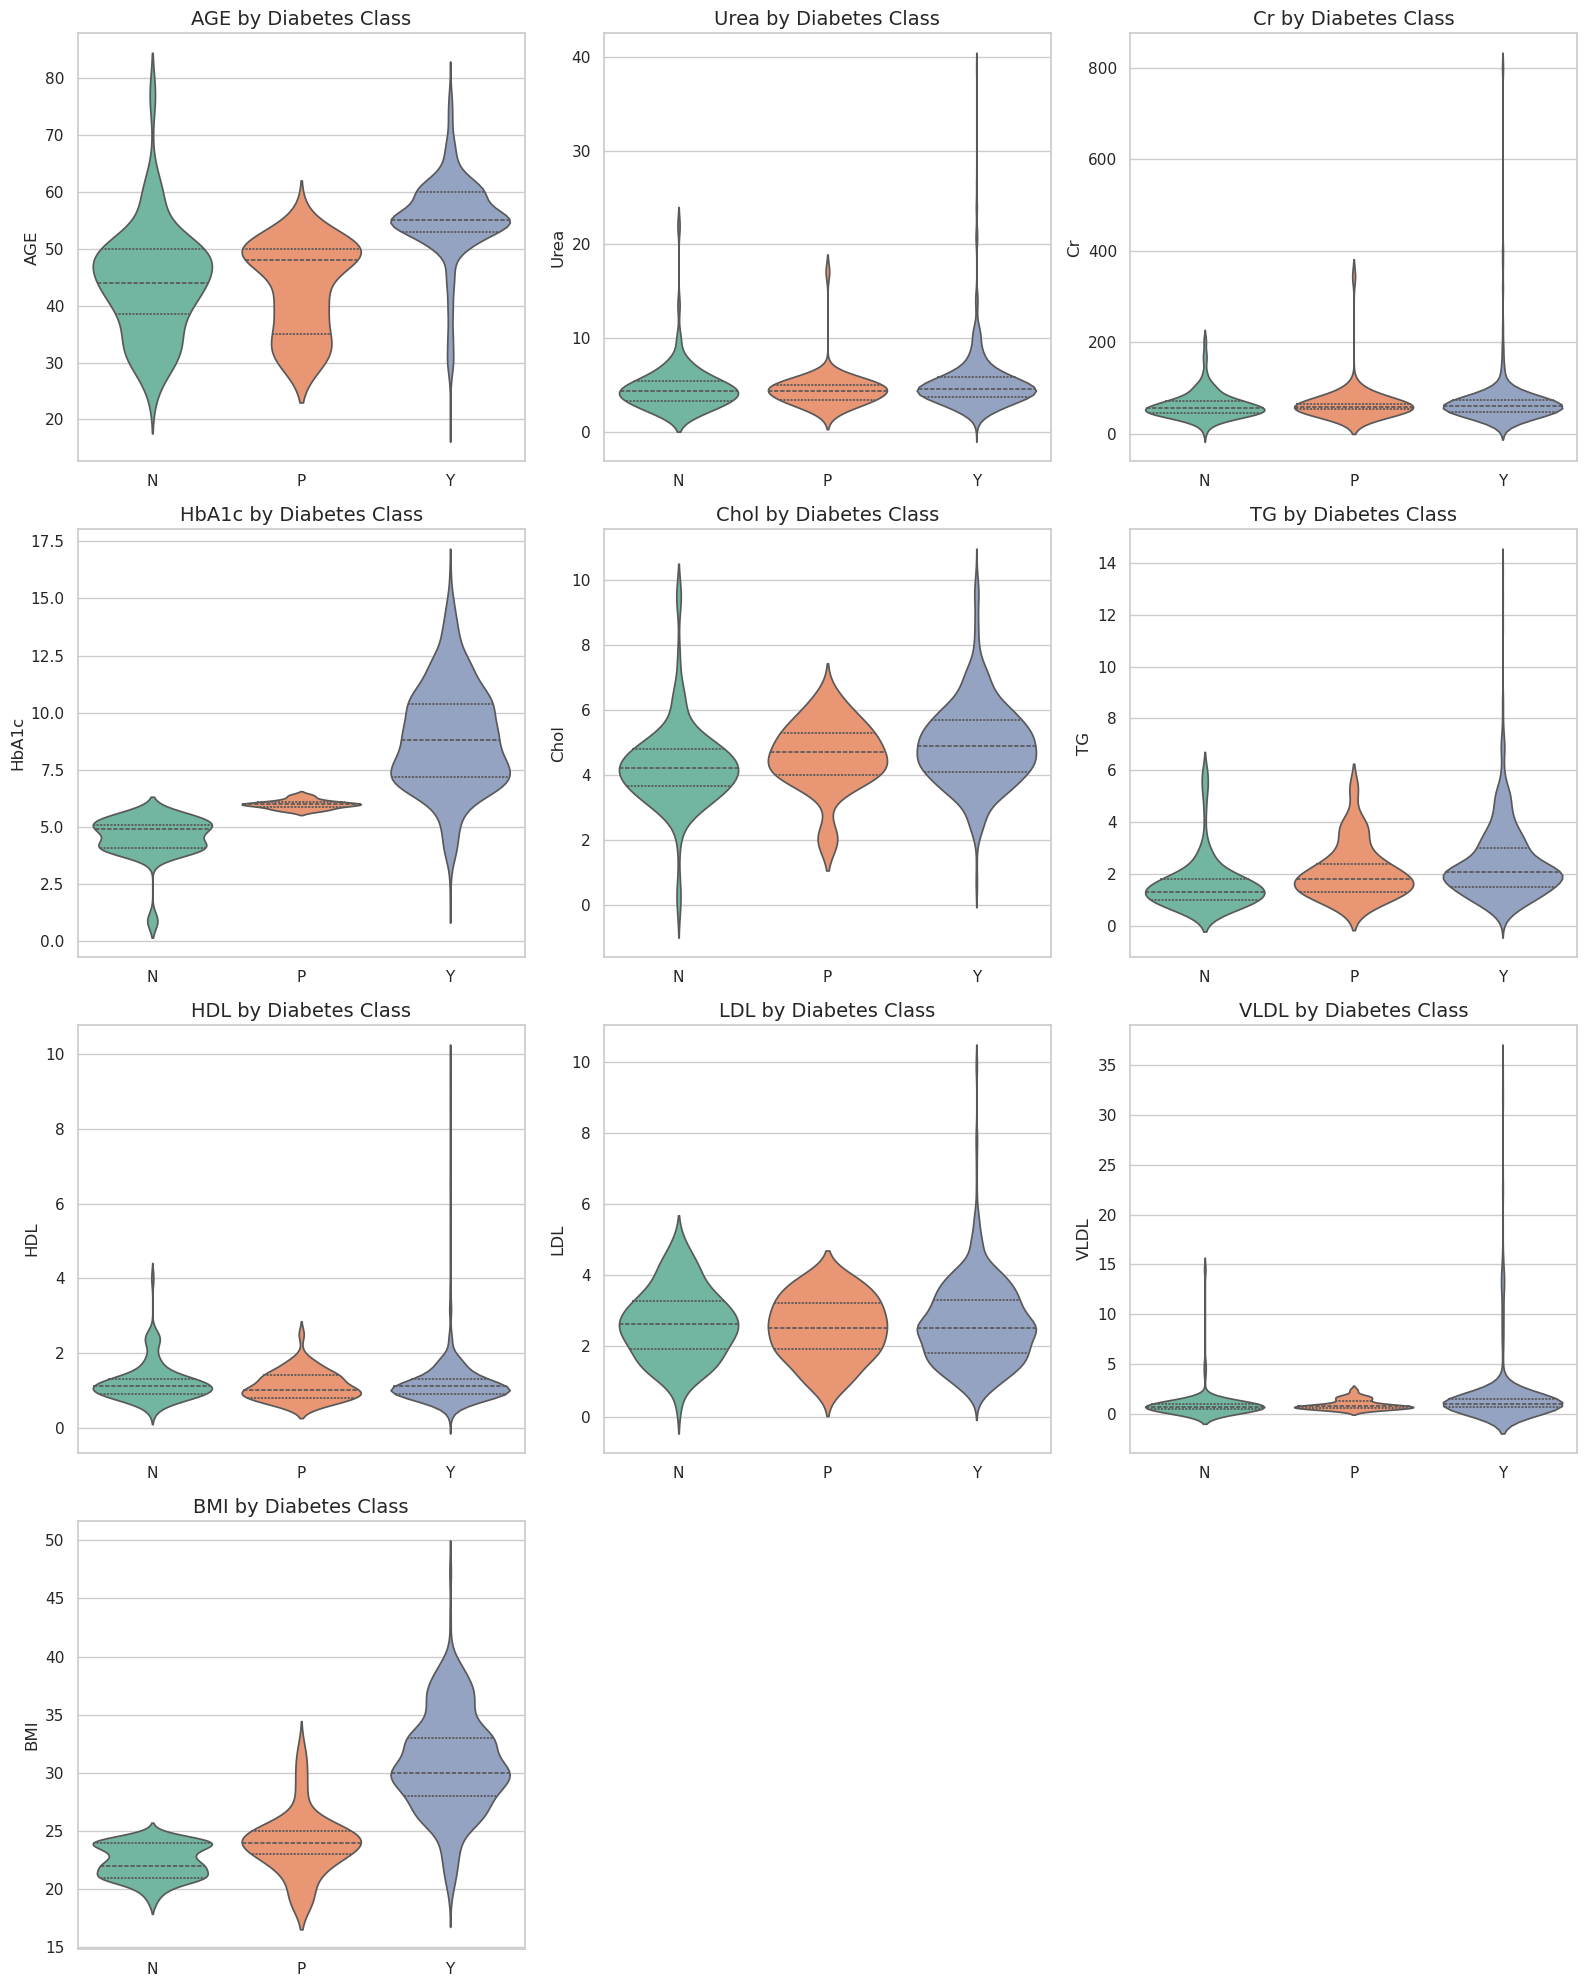

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.violinplot(data=df, x='CLASS', y=col, order=['N', 'P', 'Y'],
                   palette='Set2', ax=axes[i], inner='quartile')
    axes[i].set_title(f'{col} by Diabetes Class')
    axes[i].set_xlabel('')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3.3 Class-wise Mean Comparison

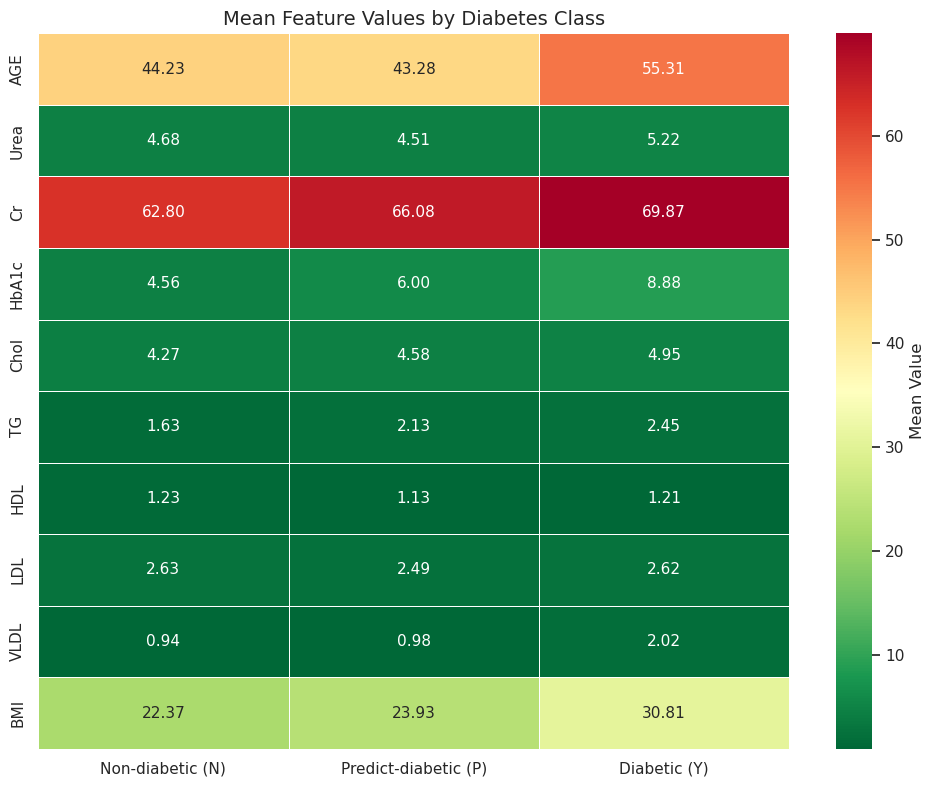

In [14]:
# Mean values per class
class_means = df.groupby('CLASS')[numeric_cols].mean().T
class_means.columns = ['Non-diabetic (N)', 'Predict-diabetic (P)', 'Diabetic (Y)']

# Heatmap of class-wise means
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(class_means, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
ax.set_title('Mean Feature Values by Diabetes Class')
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis — Multivariate

### 4.1 Correlation Heatmap

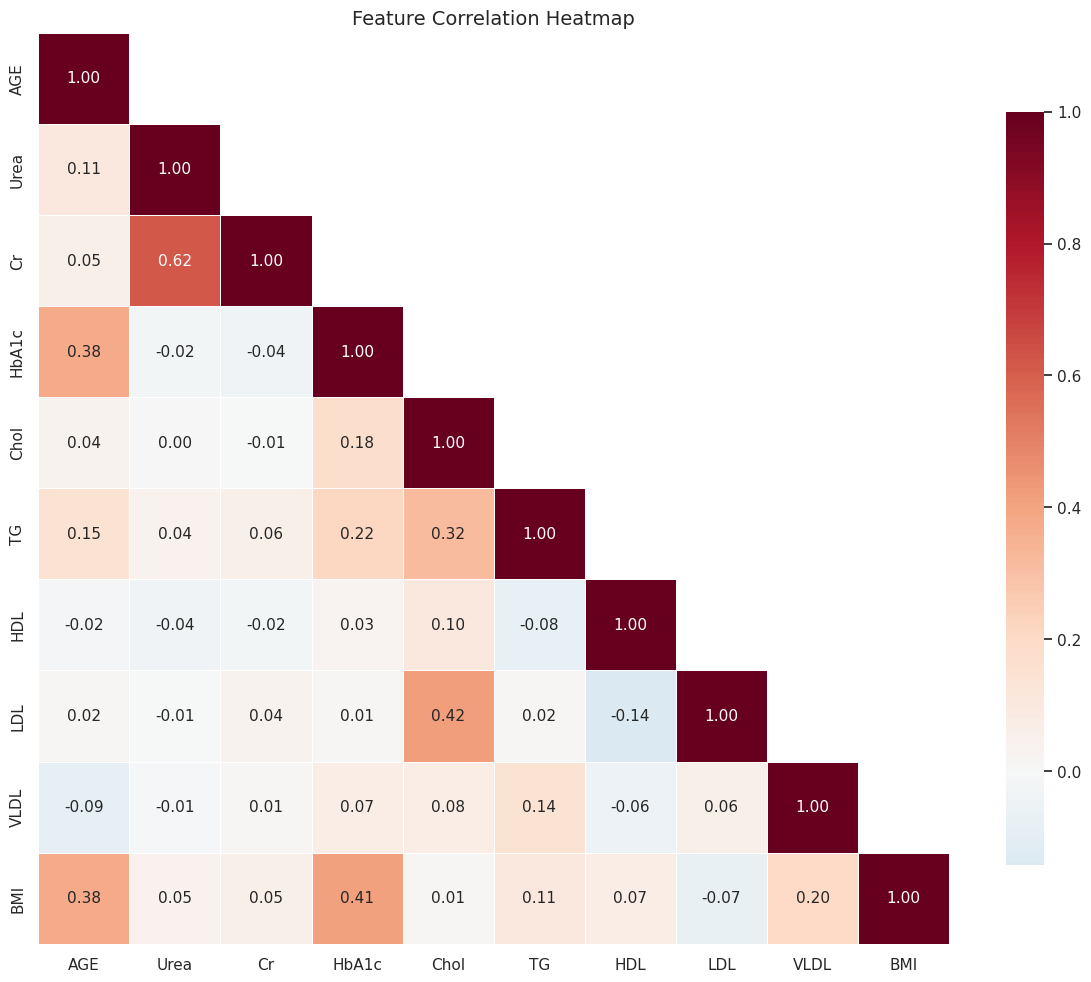

Strong feature correlations (|r| > 0.7):
  None found.


In [15]:
# Pearson correlation matrix
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Find strong correlations
print('Strong feature correlations (|r| > 0.7):')
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))
if strong_corr:
    for a, b, v in strong_corr:
        print(f'  {a} — {b}: {v:.3f}')
else:
    print('  None found.')

### 4.2 Pairplot of Key Features

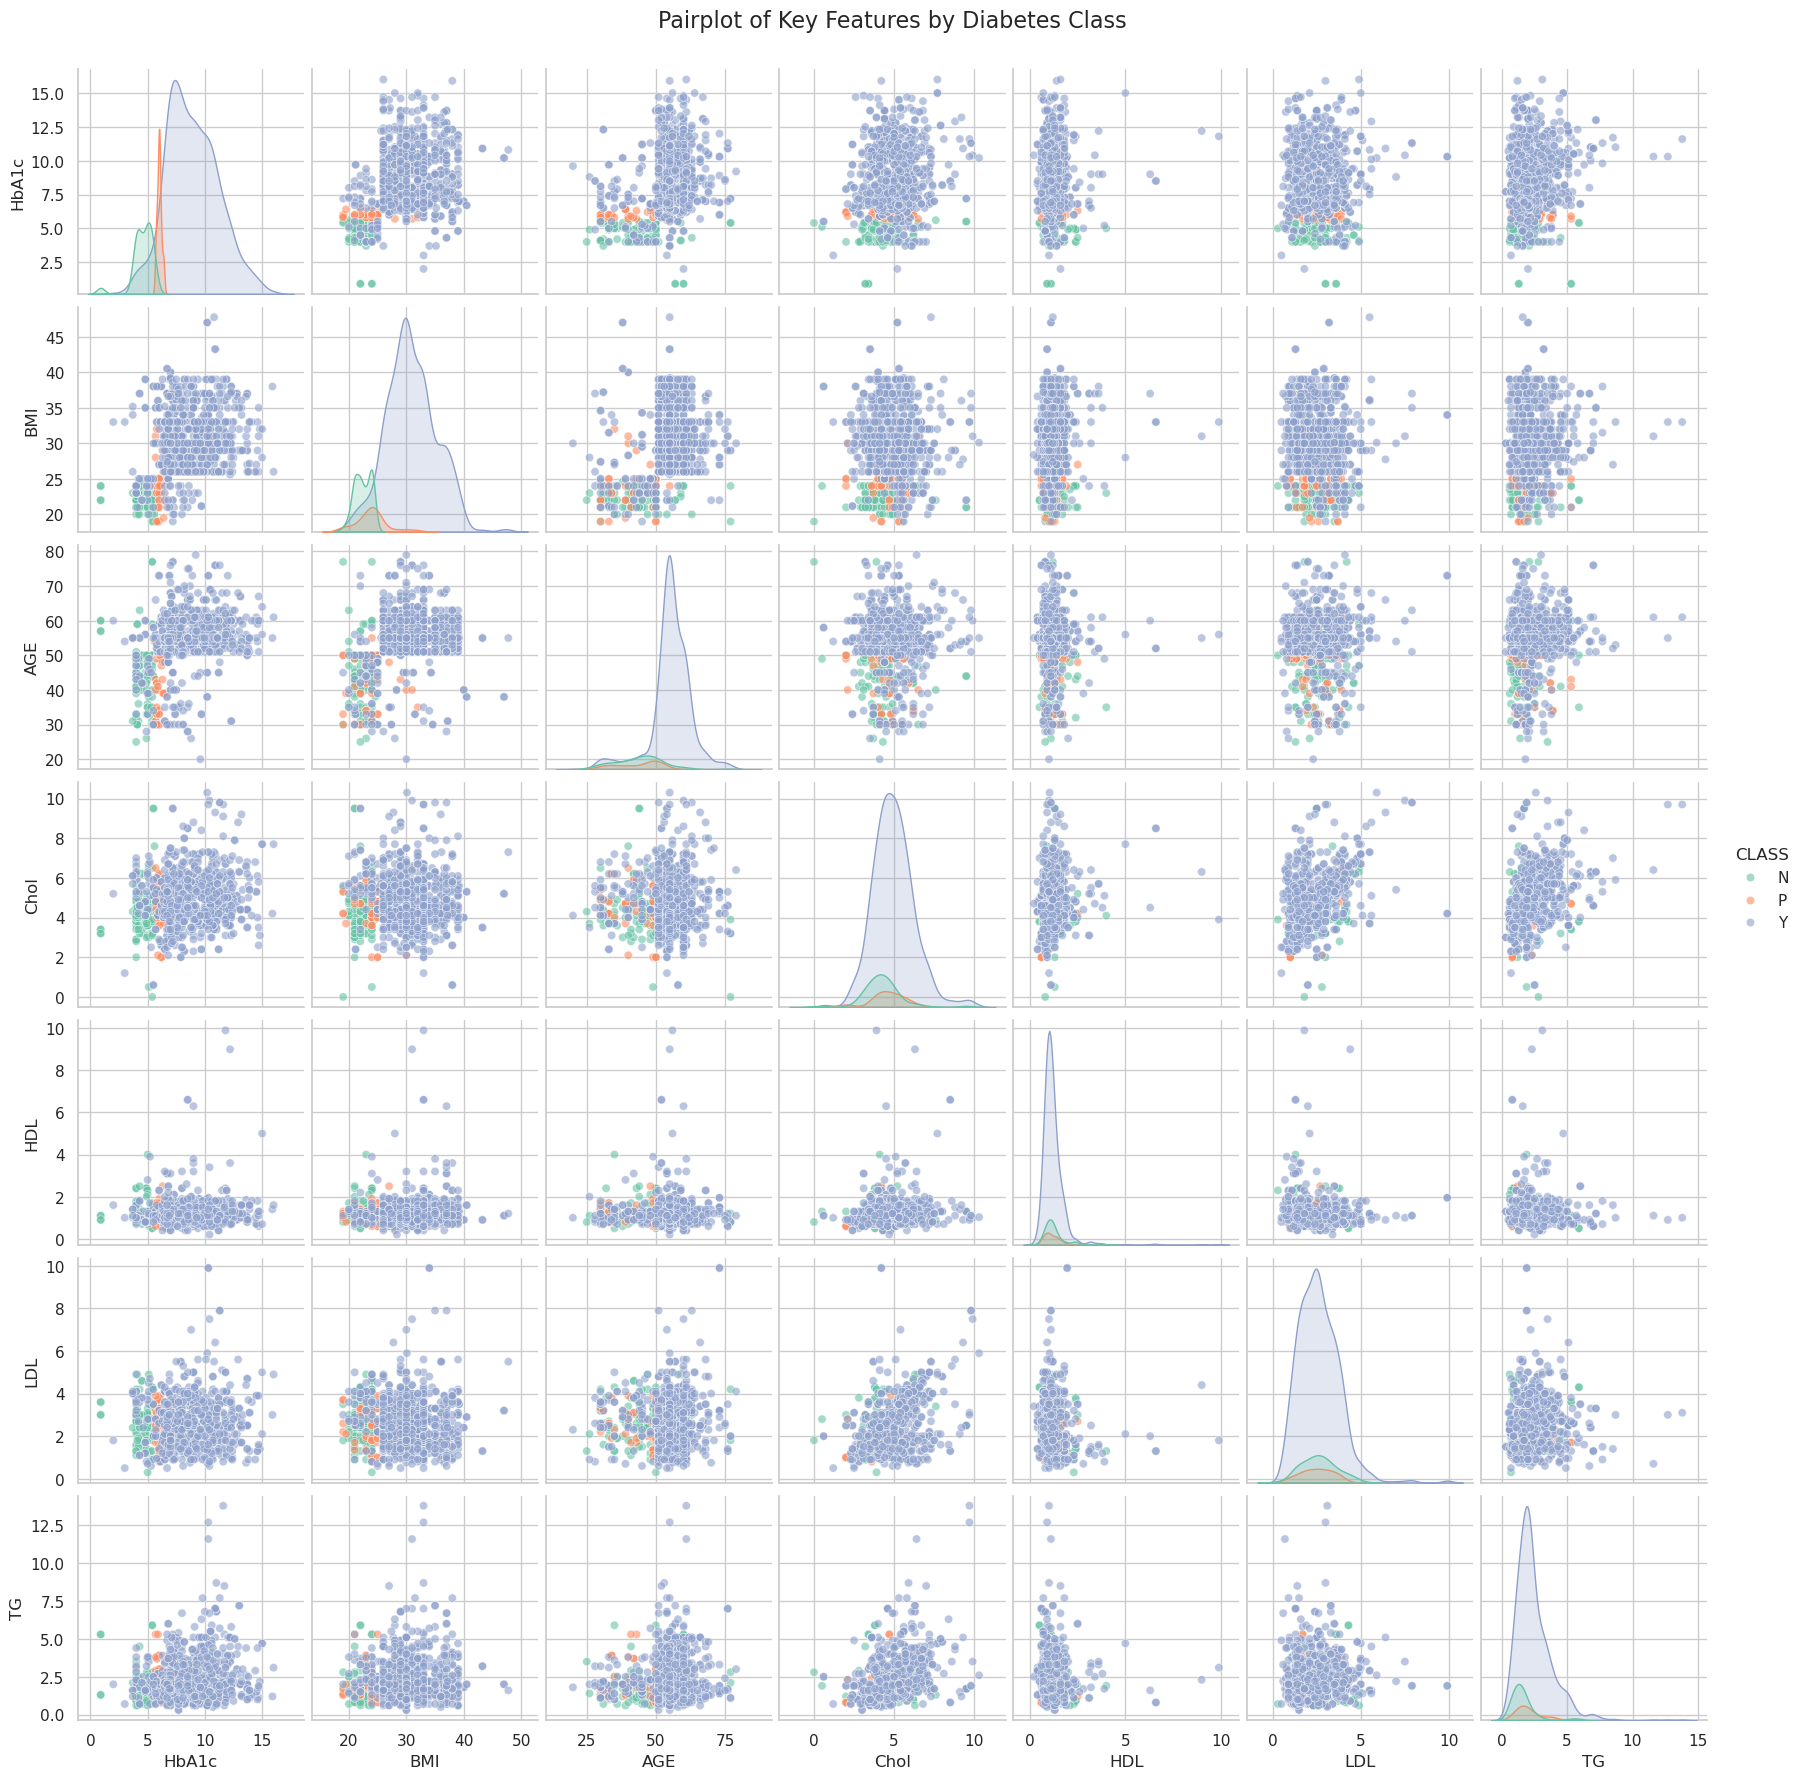

In [16]:
# Select top features based on visual differentiation
# Prioritize HbA1c, BMI, AGE, and lipid profile
key_features = ['HbA1c', 'BMI', 'AGE', 'Chol', 'HDL', 'LDL', 'TG']
g = sns.pairplot(df, vars=key_features, hue='CLASS', palette='Set2',
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot of Key Features by Diabetes Class', y=1.02, fontsize=16)
plt.show()

### 4.3 ANOVA F-Test — Feature Discriminative Power

ANOVA F-Test Results (ranking features by discriminative power):


,Feature,F-Score,p-value
9,BMI,254.605633,4.714323e-90
3,HbA1c,226.145613,1.031427e-81
0,AGE,141.792182,6.405477e-55
5,TG,17.233240,4.386920e-08
4,Chol,14.382182,6.955116e-07
8,VLDL,5.601305,3.810216e-03
1,Urea,2.767651,6.329202e-02
2,Cr,0.702425,4.956277e-01
6,HDL,0.427212,6.524445e-01
7,LDL,0.308164,7.348649e-01


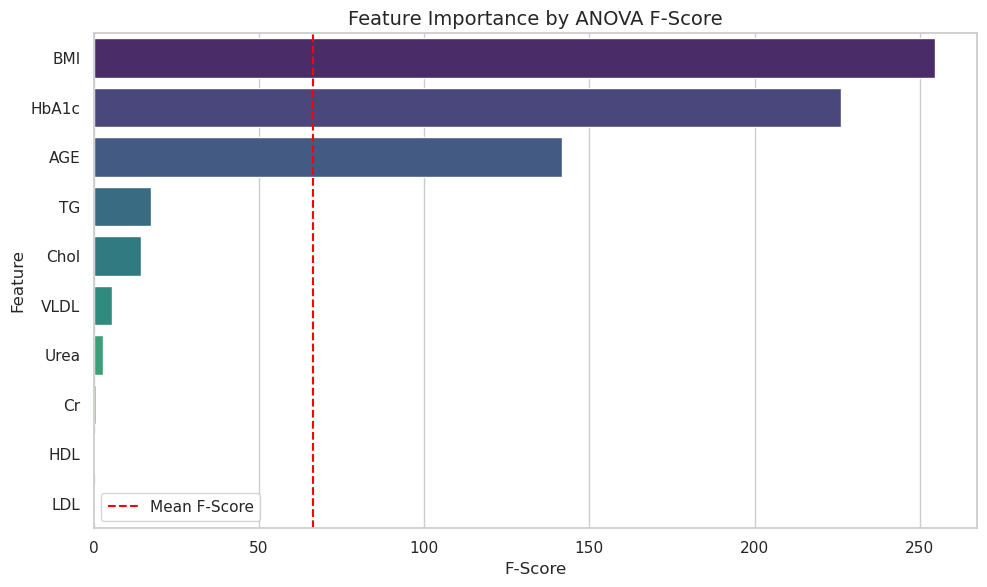

In [17]:
from sklearn.feature_selection import f_classif

# Encode CLASS for ANOVA
y_encoded = LabelEncoder().fit_transform(df['CLASS'])

# Compute ANOVA F-values
f_scores, p_values = f_classif(df[numeric_cols], y_encoded)

anova_df = pd.DataFrame({
    'Feature': numeric_cols,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values('F-Score', ascending=False)

print('ANOVA F-Test Results (ranking features by discriminative power):')
display(anova_df)

# Bar plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=anova_df, y='Feature', x='F-Score', palette='viridis', ax=ax)
ax.set_title('Feature Importance by ANOVA F-Score')
ax.axvline(anova_df['F-Score'].mean(), color='red', linestyle='--', label='Mean F-Score')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Outlier Detection and Analysis

### 5.1 IQR-Based Outlier Detection

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,AGE,51.0,59.0,8.0,39.00,71.00,98,9.8
8,VLDL,0.7,1.5,0.8,-0.50,2.70,74,7.4
1,Urea,3.7,5.7,2.0,0.70,8.70,65,6.5
5,TG,1.5,2.9,1.4,-0.60,5.00,55,5.5
2,Cr,48.0,73.0,25.0,10.50,110.50,52,5.2
6,HDL,0.9,1.3,0.4,0.30,1.90,50,5.0
4,Chol,4.0,5.6,1.6,1.60,8.00,27,2.7
7,LDL,1.8,3.3,1.5,-0.45,5.55,11,1.1
3,HbA1c,6.5,10.2,3.7,0.95,15.75,6,0.6
9,BMI,26.0,33.0,7.0,15.50,43.50,3,0.3


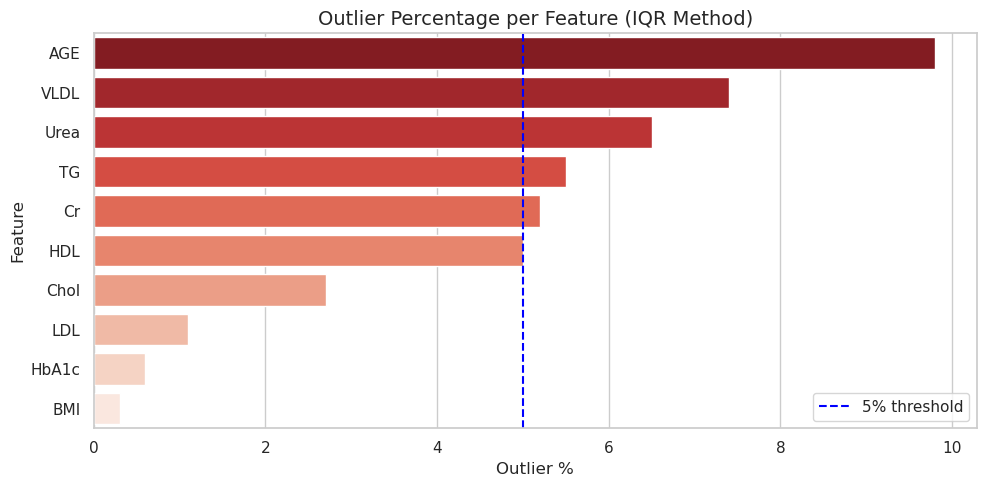

In [18]:
# IQR-based outlier detection for each numeric feature
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'Feature': col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
display(outlier_df)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=outlier_df, y='Feature', x='Outlier %', palette='Reds_r', ax=ax)
ax.set_title('Outlier Percentage per Feature (IQR Method)')
ax.axvline(5, color='blue', linestyle='--', label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Domain-Specific Outlier Review

Clinical thresholds for flagging implausible values:

- **Cr (Creatinine):** Normal ~0.6–1.3 mg/dL; values >200 suggest end-stage renal disease or data error
- **HbA1c:** Normal <5.7%; values <3% are physiologically implausible
- **Chol:** Values near 0 are likely data errors

In [19]:
# Flag clinically implausible values
clinically_extreme = pd.DataFrame()
clinically_extreme['Cr > 200'] = df['Cr'] > 200
clinically_extreme['HbA1c < 3'] = df['HbA1c'] < 3
clinically_extreme['Chol < 0.5'] = df['Chol'] < 0.5
clinically_extreme['BMI > 60'] = df['BMI'] > 60
clinically_extreme['TG < 0.1'] = df['TG'] < 0.1

print('Clinically implausible values flagged:')
for col in clinically_extreme.columns:
    count = clinically_extreme[col].sum()
    if count > 0:
        print(f'  {col}: {count} rows')
        display(df[clinically_extreme[col]][['AGE', 'Cr', 'HbA1c', 'Chol', 'BMI', 'CLASS']].head())

Clinically implausible values flagged:
  Cr > 200: 17 rows


,AGE,Cr,HbA1c,Chol,BMI,CLASS
91,50.0,203.0,5.4,3.8,22.0,N
151,30.0,344.0,6.0,4.9,21.0,P
208,57.0,370.0,6.8,4.0,37.0,Y
212,57.0,370.0,6.8,6.1,37.0,Y
273,58.0,800.0,9.1,6.6,33.0,Y


  HbA1c < 3: 5 rows


,AGE,Cr,HbA1c,Chol,BMI,CLASS
80,57.0,97.0,0.9,3.2,22.0,N
92,60.0,70.0,0.9,3.4,24.0,N
98,60.0,70.0,0.9,3.4,24.0,N
101,57.0,97.0,0.9,3.2,22.0,N
554,60.0,74.0,2.0,5.2,33.0,Y


  Chol < 0.5: 1 rows


,AGE,Cr,HbA1c,Chol,BMI,CLASS
99,77.0,106.0,5.4,0.0,19.0,N


### 5.3 Outlier Treatment Strategy

- **Tree-based models** (Random Forest, XGBoost) are robust to outliers — no capping needed
- **Linear models** (Logistic Regression) benefit from capped/transformed features
- **For linear models:** Apply `RobustScaler` or a `QuantileTransformer` as alternative to `StandardScaler`
- **For clinically implausible values:** Cap at reasonable bounds using domain knowledge
- **Moderate outliers:** Retain — they carry important clinical signal (sick patients have extreme values)

## 6. Data Preprocessing

### 6.1 Train-Test Split (Stratified)

In [20]:
# Separate features and target
X = df.drop(columns=['CLASS'])
y = df['CLASS']

# Encode target: N=0, P=1, Y=2
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f'Class mapping: {dict(zip(label_encoder.classes_, range(3)))}')
print(f'Target distribution: {dict(zip(label_encoder.classes_, np.bincount(y_encoded)))}')

# Stratified split preserves class proportions in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nTrain class distribution:')
for cls, count in zip(label_encoder.classes_, np.bincount(y_train)):
    print(f'  {cls}: {count} ({count/len(y_train)*100:.1f}%)')
print(f'\nTest class distribution:')
for cls, count in zip(label_encoder.classes_, np.bincount(y_test)):
    print(f'  {cls}: {count} ({count/len(y_test)*100:.1f}%)')

Class mapping: {'N': 0, 'P': 1, 'Y': 2}
Target distribution: {'N': 103, 'P': 53, 'Y': 844}

Training set: 800 samples
Test set: 200 samples

Train class distribution:
  N: 82 (10.2%)
  P: 43 (5.4%)
  Y: 675 (84.4%)

Test class distribution:
  N: 21 (10.5%)
  P: 10 (5.0%)
  Y: 169 (84.5%)


### 6.2 Feature Encoding and Scaling

- **Gender:** Binary → Label Encode (F=0, M=1)
- **Numeric features:** StandardScaler (z-score normalization)
- Combined with `ColumnTransformer`

In [21]:
# Identify column types
numeric_features = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
categorical_features = ['Gender']

# Build preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print('Preprocessor: StandardScaler + OneHotEncoder(drop=first)')

Numeric features (10): ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
Categorical features (1): ['Gender']
Preprocessor: StandardScaler + OneHotEncoder(drop=first)


### 6.3 Handling Class Imbalance with SMOTE

The dataset is severely imbalanced (Y=844, N=103, P=53). SMOTE generates synthetic samples for minority classes.

**CRITICAL:** SMOTE must be applied ONLY to training data and WITHIN cross-validation folds to prevent data leakage.

Class distribution BEFORE SMOTE:
  N: 82
  P: 43
  Y: 675
Class distribution AFTER SMOTE:
  N: 675
  P: 675
  Y: 675


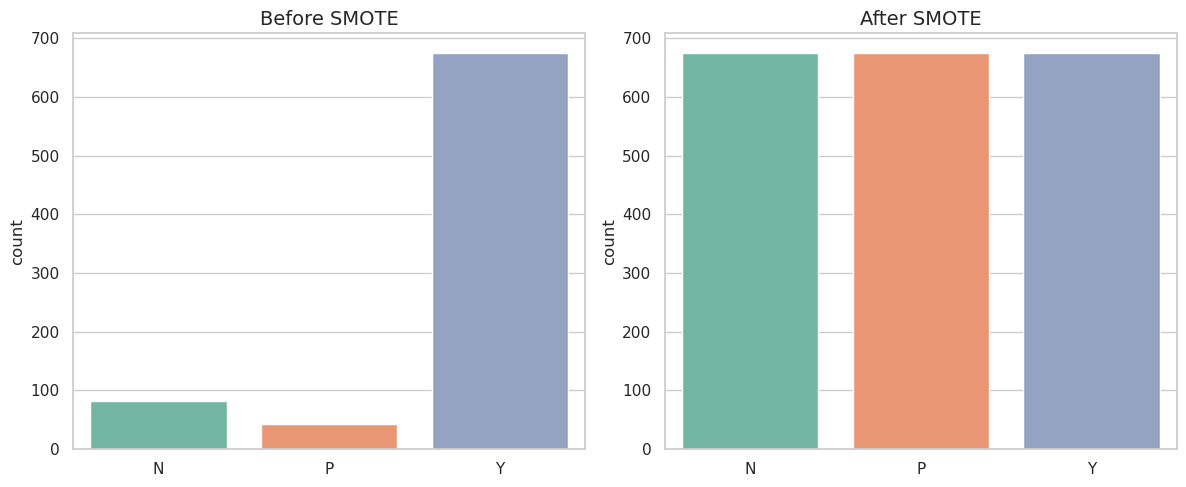

In [22]:
# Apply SMOTE to training data for visualization
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(
    preprocessor.fit_transform(X_train), y_train
)

print('Class distribution BEFORE SMOTE:')
for cls, count in zip(label_encoder.classes_, np.bincount(y_train)):
    print(f'  {cls}: {count}')

print('Class distribution AFTER SMOTE:')
for cls, count in zip(label_encoder.classes_, np.bincount(y_train_smote)):
    print(f'  {cls}: {count}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=[label_encoder.inverse_transform([i])[0] for i in y_train],
              order=['N', 'P', 'Y'], palette='Set2', ax=axes[0])
axes[0].set_title('Before SMOTE')
sns.countplot(x=[label_encoder.inverse_transform([i])[0] for i in y_train_smote],
              order=['N', 'P', 'Y'], palette='Set2', ax=axes[1])
axes[1].set_title('After SMOTE')
plt.tight_layout()
plt.show()

### 6.4 Pipeline-Ready Preprocessor

For proper cross-validation, we will use `imblearn.pipeline.Pipeline` (not sklearn's) to chain:
1. **ColumnTransformer** (scale numeric, encode categorical)
2. **SMOTE** (oversample minority classes)
3. **Classifier** (any sklearn-compatible model)

This ensures SMOTE is applied fold-by-fold during cross-validation, preventing data leakage.

## 7. Classification — Baseline Models

### 7.1 Dummy Classifier (Lower Bound)

A model that always predicts the majority class (Y). Any useful model must beat this.

In [23]:
# Dummy classifier — always predicts the majority class (Y)
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print(f'Dummy Classifier (most_frequent) — Test Accuracy: {accuracy_score(y_test, dummy_pred):.4f}')
print(f'Dummy Classifier — Test F1-macro: {f1_score(y_test, dummy_pred, average="macro"):.4f}')

print('Classification Report (Dummy):')
print(classification_report(y_test, dummy_pred, target_names=label_encoder.classes_))

Dummy Classifier (most_frequent) — Test Accuracy: 0.8450
Dummy Classifier — Test F1-macro: 0.3053
Classification Report (Dummy):
              precision    recall  f1-score   support

           N       0.00      0.00      0.00        21
           P       0.00      0.00      0.00        10
           Y       0.84      1.00      0.92       169

    accuracy                           0.84       200
   macro avg       0.28      0.33      0.31       200
weighted avg       0.71      0.84      0.77       200



## 8. Classification — Model Training with Cross-Validation

### 8.1 Model Definitions

Five models with imblearn pipelines (preprocessing + SMOTE + classifier):

| Model | Rationale |
|---|---|
| Logistic Regression | Linear baseline, interpretable coefficients |
| Random Forest | Ensemble, robust to outliers, built-in feature importance |
| XGBoost | Gradient boosting, state-of-the-art for tabular data |
| SVC (RBF Kernel) | Margin-based, captures non-linear boundaries |
| K-Nearest Neighbors | Distance-based, non-parametric contrast |

In [24]:
# Build pipelines (imblearn pipelines so SMOTE applies fold-by-fold in CV)
pipelines = {
    'Logistic Regression': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'Random Forest': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                              random_state=RANDOM_STATE))
    ]),
    'XGBoost': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', XGBClassifier(n_estimators=200, eval_metric='mlogloss',
                                      random_state=RANDOM_STATE))
    ]),
    'SVC': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
    ]),
    'KNN': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ])
}

print('Pipelines defined for 5 models.')

Pipelines defined for 5 models.


### 8.2 Stratified 5-Fold Cross-Validation

Primary metric: **F1-macro** (treats all classes equally despite imbalance)

In [25]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']

# Run CV for each model
cv_results = {}
for name, pipe in pipelines.items():
    print(f'Running CV for {name}...')
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring,
                           return_train_score=False, n_jobs=-1)
    cv_results[name] = {
        'Accuracy': scores['test_accuracy'].mean(),
        'F1-Macro': scores['test_f1_macro'].mean(),
        'F1-Weighted': scores['test_f1_weighted'].mean(),
        'Precision-Macro': scores['test_precision_macro'].mean(),
        'Recall-Macro': scores['test_recall_macro'].mean(),
        'Fit Time (s)': scores['fit_time'].mean()
    }

# Results table
cv_df = pd.DataFrame(cv_results).T.round(4)
cv_df = cv_df.sort_values('F1-Macro', ascending=False)
print('\nCross-Validation Results (5-fold, mean scores):')
display(cv_df)

# Highlight best
best_model_name = cv_df.index[0]
print(f'\nBest model by F1-Macro: {best_model_name} ({cv_df.iloc[0]["F1-Macro"]:.4f})')

Running CV for Logistic Regression...


Running CV for Random Forest...


Running CV for XGBoost...


Running CV for SVC...


Running CV for KNN...

Cross-Validation Results (5-fold, mean scores):


,Accuracy,F1-Macro,F1-Weighted,Precision-Macro,Recall-Macro,Fit Time (s)
XGBoost,0.9850,0.9676,0.9852,0.9686,0.9685,0.6733
Random Forest,0.9775,0.9504,0.9776,0.9541,0.9527,0.3582
SVC,0.9175,0.7892,0.9228,0.7516,0.8469,0.0917
KNN,0.9050,0.7602,0.9146,0.7173,0.8473,0.0088
Logistic Regression,0.9000,0.7559,0.9118,0.7102,0.8478,0.0185



Best model by F1-Macro: XGBoost (0.9676)


### 8.3 CV Results Visualization

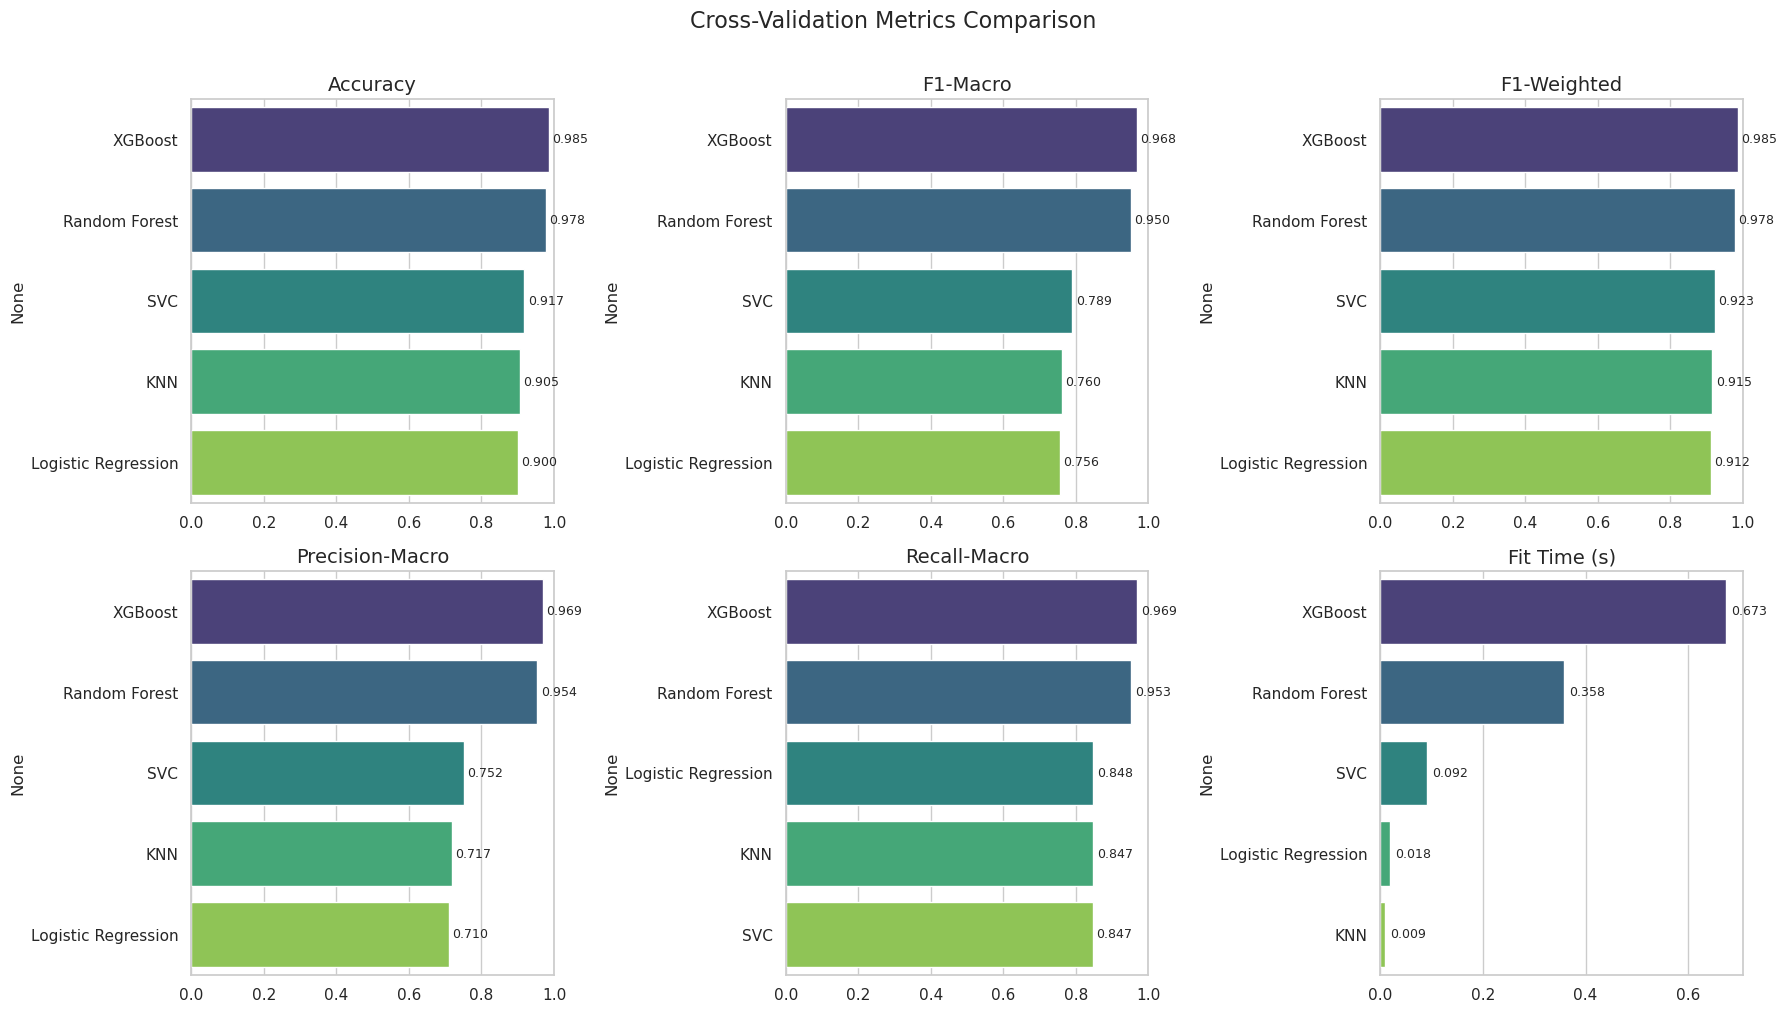

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
metrics = ['Accuracy', 'F1-Macro', 'F1-Weighted', 'Precision-Macro', 'Recall-Macro', 'Fit Time (s)']

for i, metric in enumerate(metrics):
    vals = cv_df[metric].sort_values(ascending=False)
    sns.barplot(x=vals.values, y=vals.index, palette='viridis', ax=axes[i])
    axes[i].set_title(metric)
    if i < 5:
        axes[i].set_xlim(0, 1)
    for j, v in enumerate(vals.values):
        axes[i].text(v + 0.01, j, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Cross-Validation Metrics Comparison', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 9. Classification — Test Set Evaluation

### 9.1 Train on Full Training Set, Predict on Test Set

In [27]:
# Train all models on full training set and evaluate on test set
test_results = {}
predictions = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred
    test_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Macro': f1_score(y_test, y_pred, average='macro'),
        'F1-Weighted': f1_score(y_test, y_pred, average='weighted'),
        'Precision-Macro': precision_score(y_test, y_pred, average='macro'),
        'Recall-Macro': recall_score(y_test, y_pred, average='macro')
    }

test_df = pd.DataFrame(test_results).T.round(4)
test_df = test_df.sort_values('F1-Macro', ascending=False)
print('Test Set Performance:')
display(test_df)

# Compare CV vs Test
print('\nCV F1-Macro vs Test F1-Macro:')
comparison = pd.DataFrame({
    'CV F1-Macro': cv_df['F1-Macro'],
    'Test F1-Macro': test_df['F1-Macro'],
    'Difference': (cv_df['F1-Macro'] - test_df['F1-Macro']).abs()
}).sort_values('Test F1-Macro', ascending=False)
display(comparison)

# Identify top 2 models
top2 = test_df.index[:2].tolist()
print(f'Top 2 models for detailed analysis: {" and ".join(top2)}')

Test Set Performance:


,Accuracy,F1-Macro,F1-Weighted,Precision-Macro,Recall-Macro
Random Forest,0.995,0.9815,0.9949,0.9980,0.9667
XGBoost,0.990,0.9724,0.9898,0.9961,0.9508
SVC,0.955,0.8598,0.9571,0.8360,0.8917
KNN,0.945,0.8418,0.9493,0.8045,0.9052
Logistic Regression,0.930,0.7757,0.9347,0.7558,0.8052



CV F1-Macro vs Test F1-Macro:


,CV F1-Macro,Test F1-Macro,Difference
Random Forest,0.9504,0.9815,0.0311
XGBoost,0.9676,0.9724,0.0048
SVC,0.7892,0.8598,0.0706
KNN,0.7602,0.8418,0.0816
Logistic Regression,0.7559,0.7757,0.0198


Top 2 models for detailed analysis: Random Forest and XGBoost


### 9.2 Per-Class Metrics for Best Models

In [28]:
# Detailed per-class metrics for top 2 models
for name in top2:
    y_pred = predictions[name]
    print(f'\n{"="*60}')
    print(f'{name} — Test Set Classification Report')
    print(f'{"="*60}')
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Random Forest — Test Set Classification Report
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.90      0.95        10
           Y       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200


XGBoost — Test Set Classification Report
              precision    recall  f1-score   support

           N       1.00      0.95      0.98        21
           P       1.00      0.90      0.95        10
           Y       0.99      1.00      0.99       169

    accuracy                           0.99       200
   macro avg       1.00      0.95      0.97       200
weighted avg       0.99      0.99      0.99       200



## 10. Error Analysis — Confusion Matrices

### 10.1 Confusion Matrices for All Models

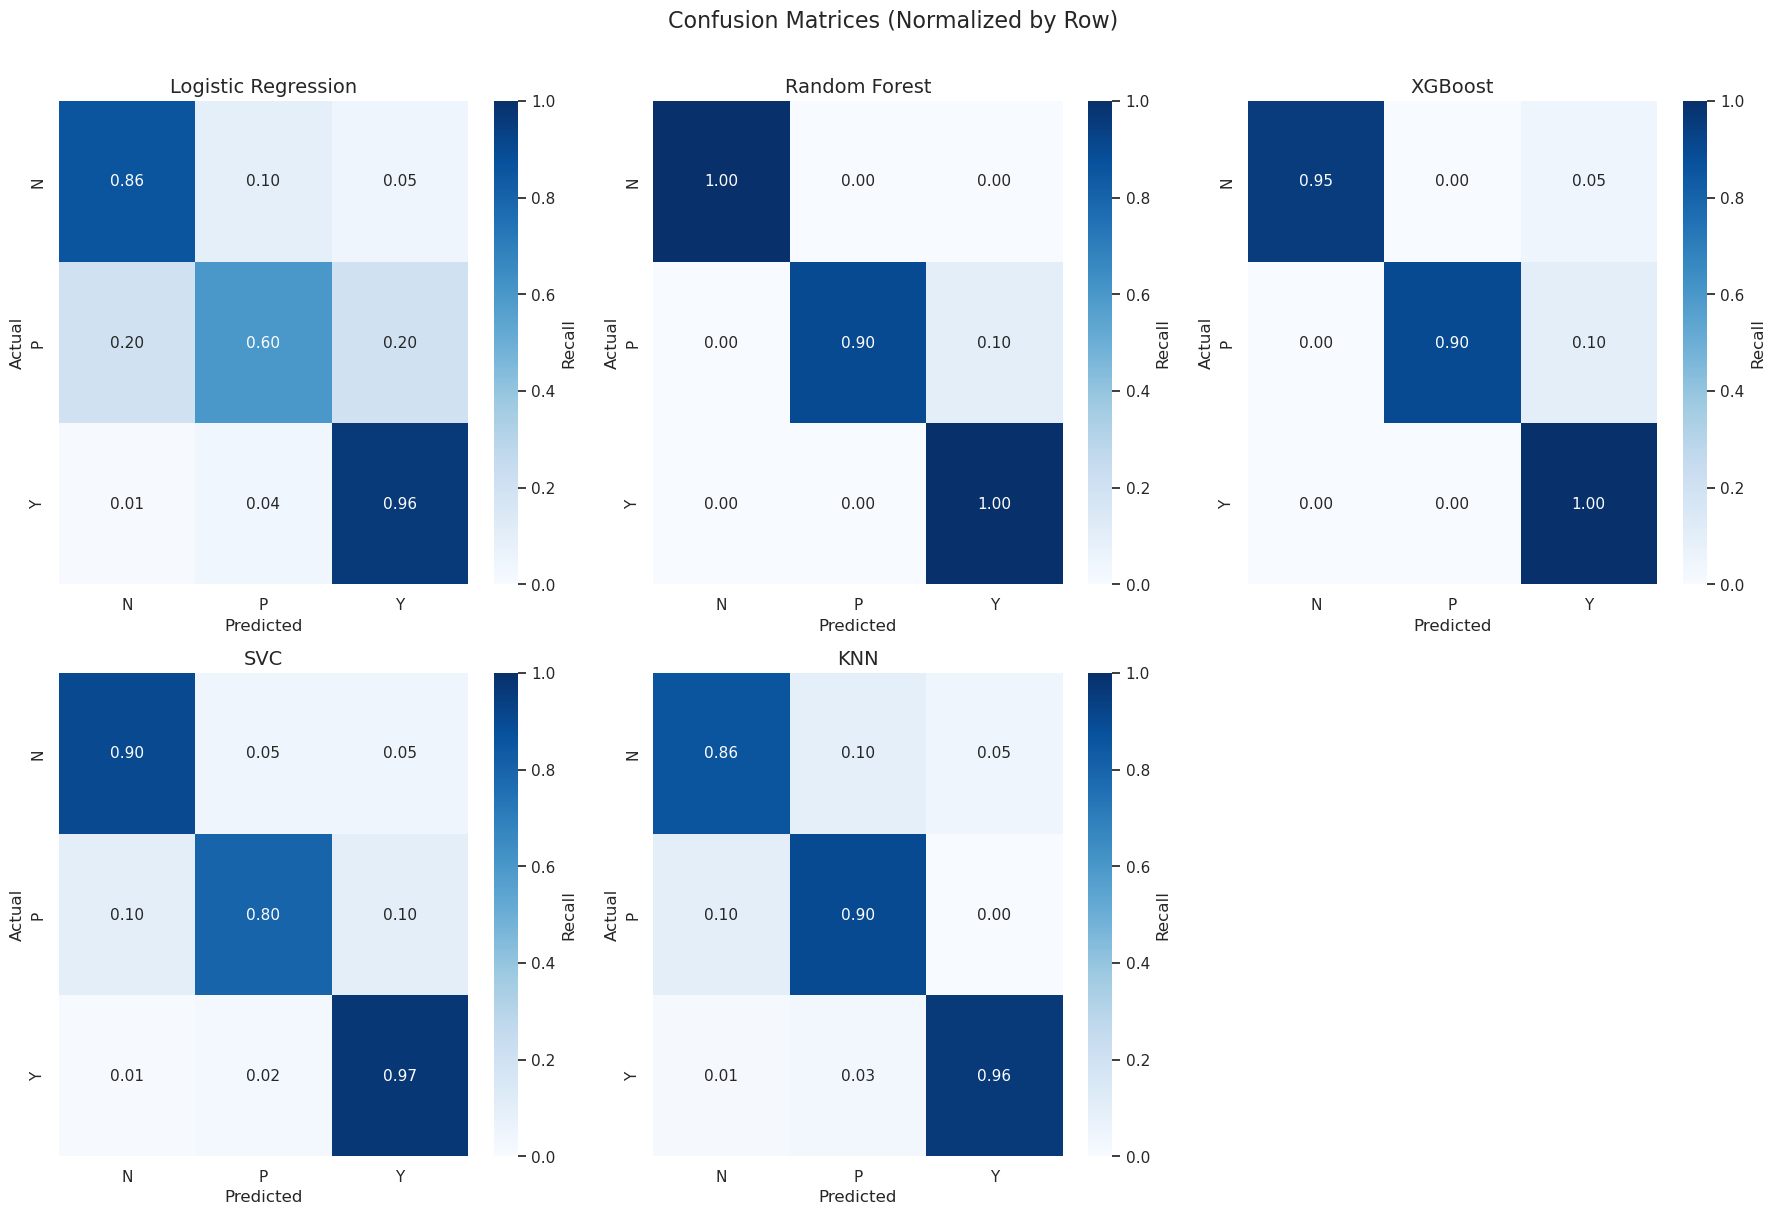

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[i],
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
                vmin=0, vmax=1, cbar_kws={'label': 'Recall'})
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide extra subplot
axes[5].set_visible(False)

plt.suptitle('Confusion Matrices (Normalized by Row)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 10.2 Per-Class F1-Score Comparison

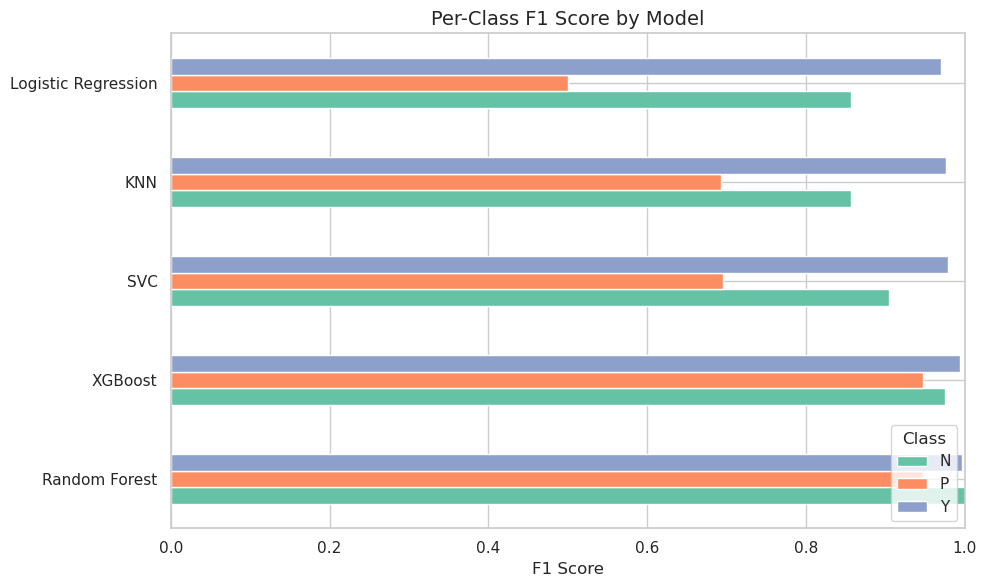

,N,P,Y
Random Forest,1.0000,0.9474,0.9971
XGBoost,0.9756,0.9474,0.9941
SVC,0.9048,0.6957,0.9791
KNN,0.8571,0.6923,0.9759
Logistic Regression,0.8571,0.5000,0.9701


In [30]:
# Extract per-class F1 scores for all models
per_class_f1 = {}
for name, y_pred in predictions.items():
    per_class_f1[name] = {
        cls: f1_score(y_test == i, (y_pred == i).astype(int))
        for i, cls in enumerate(label_encoder.classes_)
    }

per_class_df = pd.DataFrame(per_class_f1).T
per_class_df = per_class_df.sort_values('Y', ascending=False)

# Plot
per_class_df.plot(kind='barh', figsize=(10, 6), color=sns.color_palette('Set2', 3))
plt.title('Per-Class F1 Score by Model')
plt.xlabel('F1 Score')
plt.xlim(0, 1)
plt.legend(title='Class', loc='lower right')
plt.tight_layout()
plt.show()

display(per_class_df.round(4))

### 10.3 Misclassification Analysis (Best Model)

In [31]:
best_model = predictions[top2[0]]
best_model_proba = None
# Get probabilities from the best model
for name, pipe in pipelines.items():
    if name == top2[0]:
        best_model_proba = pipe.predict_proba(X_test)
        break

# Identify misclassified samples
misclassified = X_test[y_test != best_model].copy()
misclassified['True Class'] = label_encoder.inverse_transform(y_test[y_test != best_model])
misclassified['Predicted Class'] = label_encoder.inverse_transform(best_model[y_test != best_model])
misclassified['Prediction Confidence'] = best_model_proba[y_test != best_model].max(axis=1)

print(f'Total misclassifications ({top2[0]}): {len(misclassified)} out of {len(y_test)} '
      f'({len(misclassified)/len(y_test)*100:.1f}%)')

# Confusion pairs
print('\nMisclassification patterns:')
for true_cls in label_encoder.classes_:
    for pred_cls in label_encoder.classes_:
        if true_cls != pred_cls:
            count = ((misclassified['True Class'] == true_cls) &
                     (misclassified['Predicted Class'] == pred_cls)).sum()
            if count > 0:
                print(f'  {true_cls} → {pred_cls}: {count} cases')

print('\nSample misclassified cases:')
display(misclassified.head(10))

Total misclassifications (Random Forest): 1 out of 200 (0.5%)

Misclassification patterns:
  P → Y: 1 cases

Sample misclassified cases:


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,True Class,Predicted Class,Prediction Confidence
152,M,54.0,4.0,88.0,5.7,4.4,2.9,0.6,2.5,1.3,28.0,P,Y,0.755


## 11. Feature Importance Analysis

### 11.1 Built-in Feature Importance (Random Forest & XGBoost)

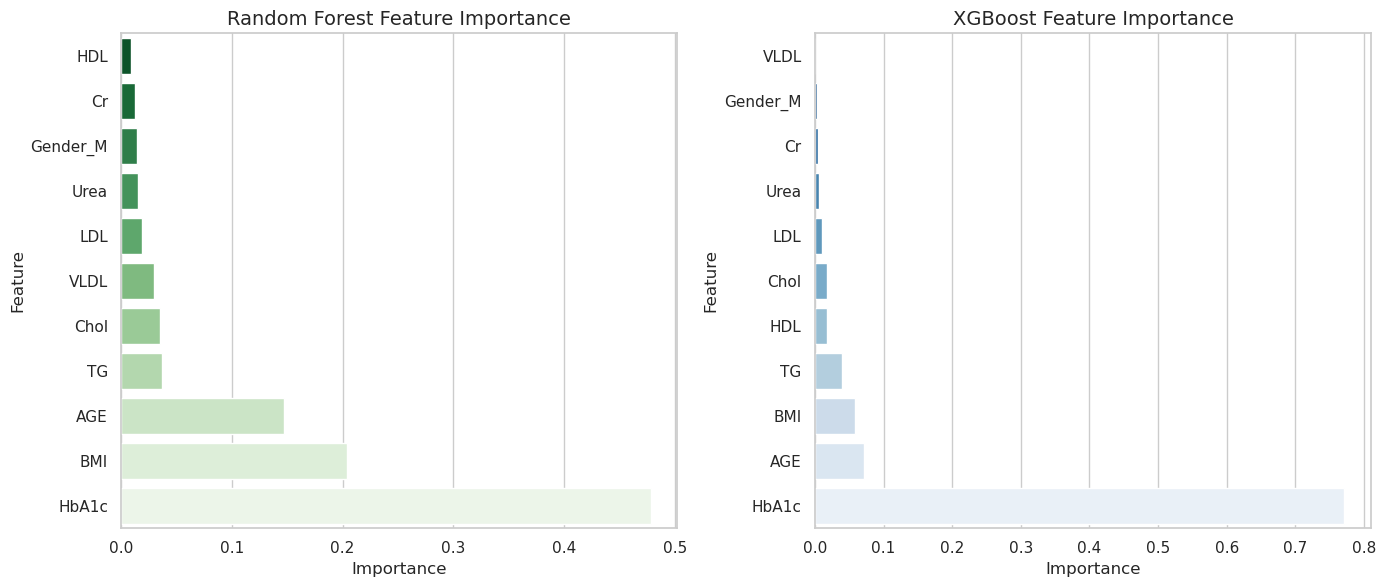

Feature Importance Comparison:


,Feature,RF Importance,XGB Importance
3,HbA1c,0.4784,0.7715
9,BMI,0.2041,0.0579
0,AGE,0.1466,0.0713
5,TG,0.0369,0.0392
4,Chol,0.0352,0.0173
8,VLDL,0.0300,0.0004
7,LDL,0.0186,0.0106
1,Urea,0.0148,0.0065
10,Gender_M,0.0142,0.0029
2,Cr,0.0126,0.0050


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
rf_pipe = pipelines['Random Forest']
rf_importances = rf_pipe.named_steps['classifier'].feature_importances_
rf_feature_names = list(rf_pipe.named_steps['preprocessor'].get_feature_names_out())
rf_feature_names_clean = [n.replace('num__', '').replace('cat__', '') for n in rf_feature_names]
rf_imp_df = pd.DataFrame({'Feature': rf_feature_names_clean, 'Importance': rf_importances}).sort_values('Importance')
sns.barplot(data=rf_imp_df, y='Feature', x='Importance', palette='Greens_r', ax=axes[0])
axes[0].set_title('Random Forest Feature Importance')

# XGBoost
xgb_pipe = pipelines['XGBoost']
xgb_importances = xgb_pipe.named_steps['classifier'].feature_importances_
xgb_feature_names = list(xgb_pipe.named_steps['preprocessor'].get_feature_names_out())
xgb_feature_names_clean = [n.replace('num__', '').replace('cat__', '') for n in xgb_feature_names]
xgb_imp_df = pd.DataFrame({'Feature': xgb_feature_names_clean, 'Importance': xgb_importances}).sort_values('Importance')
sns.barplot(data=xgb_imp_df, y='Feature', x='Importance', palette='Blues_r', ax=axes[1])
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.show()

# Comparison table
importance_comparison = pd.DataFrame({
    'Feature': rf_feature_names_clean,
    'RF Importance': rf_importances,
    'XGB Importance': xgb_importances
}).sort_values('RF Importance', ascending=False)
print('Feature Importance Comparison:')
display(importance_comparison.round(4))

### 11.2 Permutation Importance (Model-Agnostic)

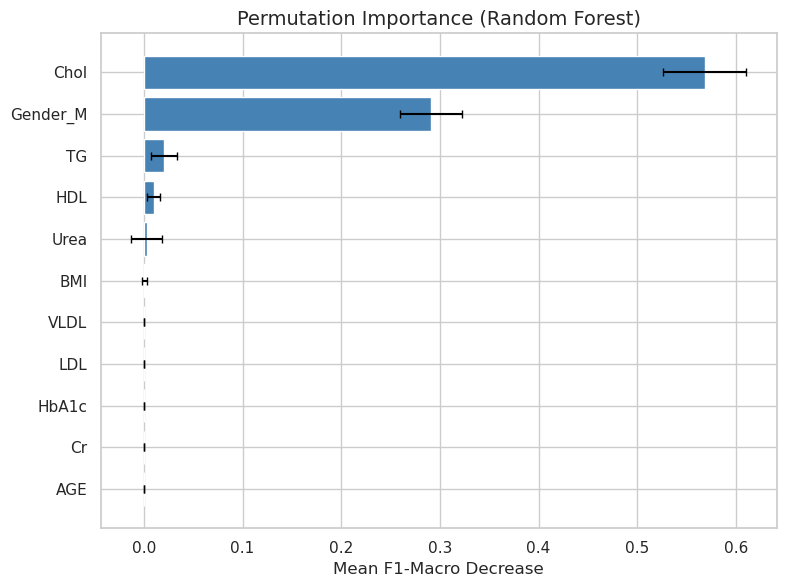

,Feature,Importance,Std
0,AGE,0.0000,0.0000
2,Cr,0.0000,0.0000
3,HbA1c,0.0000,0.0000
7,LDL,0.0000,0.0000
8,VLDL,0.0000,0.0000
9,BMI,0.0009,0.0027
1,Urea,0.0028,0.0154
6,HDL,0.0098,0.0062
5,TG,0.0204,0.0134
10,Gender_M,0.2907,0.0314


In [33]:
from sklearn.inspection import permutation_importance

# Compute permutation importance for the best model
best_pipe = pipelines[top2[0]]
# Reuse feature names from the cell above
feature_names_list = list(best_pipe.named_steps['preprocessor'].get_feature_names_out())
feature_names_clean = [n.replace('num__', '').replace('cat__', '') for n in feature_names_list]

perm_imp = permutation_importance(best_pipe, X_test, y_test, n_repeats=10,
                                  random_state=RANDOM_STATE, scoring='f1_macro')

perm_df = pd.DataFrame({
    'Feature': feature_names_clean,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(perm_df['Feature'], perm_df['Importance'], xerr=perm_df['Std'],
        color='steelblue', capsize=3)
ax.set_title(f'Permutation Importance ({top2[0]})')
ax.set_xlabel('Mean F1-Macro Decrease')
plt.tight_layout()
plt.show()

display(perm_df.round(4))

### 11.3 Logistic Regression Coefficients

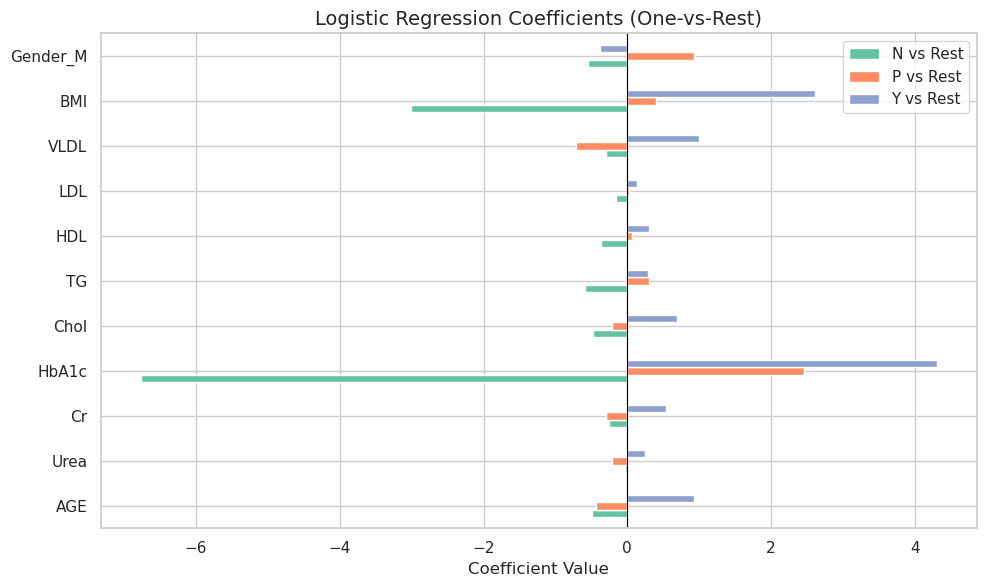

,N vs Rest,P vs Rest,Y vs Rest
AGE,-0.4896,-0.4323,0.9220
Urea,-0.0349,-0.2160,0.2509
Cr,-0.2538,-0.2894,0.5432
HbA1c,-6.7727,2.4603,4.3124
Chol,-0.4801,-0.2188,0.6989
TG,-0.5926,0.3021,0.2906
HDL,-0.3662,0.0656,0.3006
LDL,-0.1515,0.0190,0.1325
VLDL,-0.2896,-0.7110,1.0007
BMI,-3.0155,0.4034,2.6121


In [34]:
# Logistic Regression coefficients (one set per class in OvR)
lr_pipe = pipelines['Logistic Regression']
lr_coef = lr_pipe.named_steps['classifier'].coef_
feature_names_list = list(lr_pipe.named_steps['preprocessor'].get_feature_names_out())
feature_names_clean = [n.replace('num__', '').replace('cat__', '') for n in feature_names_list]

coef_df = pd.DataFrame(lr_coef.T, index=feature_names_clean,
                       columns=[f'{cls} vs Rest' for cls in label_encoder.classes_])

fig, ax = plt.subplots(figsize=(10, 6))
coef_df.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', 3))
ax.set_title('Logistic Regression Coefficients (One-vs-Rest)')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

display(coef_df.round(4))